In [49]:
# Import necessary libraries

import pandas as pd          # Data handling
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt   # Data visualization
import seaborn as sns        # Better visualization

# Machine Learning Libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Deep Learning Libraries

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [50]:
# Load dataset

df = pd.read_csv("weatherAUS.csv")

# Display first 5 rows

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [51]:
# Dataset shape

print(df.shape)

# Information

df.info()

# Statistical Summary

df.describe()

(145460, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       8

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [52]:
# Missing values

df.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [53]:
# Fill numerical columns with median

numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\BEST LAPTOP\AppData\Local\Temp\ipykernel_5340\1492767266.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\BEST LAPTOP\AppData\Local\Temp\ipykernel_5340\1492767266.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


In [54]:
# Duplicate rows

print(df.duplicated().sum())

# Remove duplicates

df.drop_duplicates(inplace=True)

0


In [55]:
# Label Encoding

encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

In [56]:
# Features

X = df.drop("RainTomorrow", axis=1)

# Target

y = df["RainTomorrow"]

In [57]:
# Standardization

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [58]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [59]:
# Create ANN

model = Sequential()

# Hidden Layer 1

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2

model.add(Dense(32, activation='relu'))

# Hidden Layer 3

model.add(Dense(16, activation='relu'))

# Output Layer

model.add(Dense(1, activation='sigmoid'))

In [60]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [61]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

910/910 [==============================] - 2s 2ms/step - loss: 0.6887 - accuracy: 0.5353
Accuracy: 0.5352674126625061


In [62]:
predictions = model.predict(X_test)

predictions = (predictions > 0.5).astype(int)

910/910 [==============================] - 2s 2ms/step


In [63]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.80      0.54      0.65     22672
           1       0.24      0.51      0.33      6420

    accuracy                           0.54     29092
   macro avg       0.52      0.53      0.49     29092
weighted avg       0.67      0.54      0.57     29092



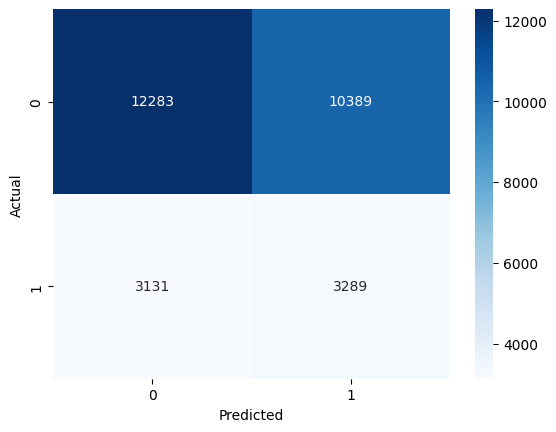

In [64]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [65]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
2910/2910 [==============================] - 12s 3ms/step - loss: 0.3612 - accuracy: 0.8428 - val_loss: 0.3549 - val_accuracy: 0.8471
Epoch 2/50
2910/2910 [==============================] - 11s 4ms/step - loss: 0.3467 - accuracy: 0.8499 - val_loss: 0.3528 - val_accuracy: 0.8501
Epoch 3/50
2910/2910 [==============================] - 10s 3ms/step - loss: 0.3420 - accuracy: 0.8528 - val_loss: 0.3476 - val_accuracy: 0.8504
Epoch 4/50
2910/2910 [==============================] - 9s 3ms/step - loss: 0.3382 - accuracy: 0.8551 - val_loss: 0.3498 - val_accuracy: 0.8494
Epoch 5/50
2910/2910 [==============================] - 9s 3ms/step - loss: 0.3362 - accuracy: 0.8554 - val_loss: 0.3440 - val_accuracy: 0.8522
Epoch 6/50
2910/2910 [==============================] - 9s 3ms/step - loss: 0.3338 - accuracy: 0.8574 - val_loss: 0.3462 - val_accuracy: 0.8491
Epoch 7/50
2910/2910 [==============================] - 9s 3ms/step - loss: 0.3319 - accuracy: 0.8572 - val_loss: 0.3456 - val_accura

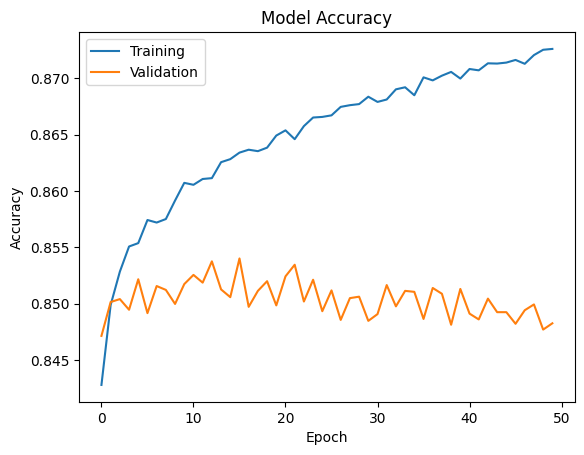

In [66]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training","Validation"])

plt.show()

In [67]:
model.save("rainfall_ann_model.keras")